# 02 · Les modèles de base, et les hypothèses de MinT mises à l'épreuve

**Bloc 5 · W37 — mini-projet éCO2mix, notebook 2 sur 4.**

On se place à **une** origine du protocole (le mardi 5 novembre 2024, 00:00 UTC), on entraîne les deux modèles
de base, puis on vérifie, une par une, les hypothèses dont MinT a besoin.

| § | Contenu | Question |
|---|---|---|
| 1 | Le découpage | Le train finit-il bien avant l'origine ? |
| 2 | Deux modèles de base | Que font SeasonalNaive et MSTL ? |
| 3 | Qui est cohérent ? | Pourquoi l'un des deux n'a pas besoin d'être réconcilié ? |
| 4 | 🔬 H1 : absence de biais | MinT suppose des prévisions de base non biaisées. Peut-on le tester ici ? |
| 5 | 🔬 H2 : résidus sans structure | Les résidus sont-ils du bruit blanc ? |
| 6 | 🔬 H3 : la matrice W | Que dit W des liens entre régions ? Est-elle bien conditionnée ? |
| 7 | ⚠️ L'hypothèse cachée | Les résidus in-sample ressemblent-ils aux vraies erreurs de prévision ? |

> **Comment lire ce notebook.** Les encadrés suivent un code fixe :
> 💡 **Intuition**, l'idée sans les équations · 🧪 **Exemple**, une expérience chiffrée ·
> ⚠️ **Point d'attention**, le piège à éviter · 📌 **À retenir**, le mémo à garder ·
> 🔬 **Test d'hypothèse**, une hypothèse formulée, testée, puis acceptée ou rejetée.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown

from w37_reconciliation import viz
from w37_reconciliation.eco2mix import run, prepare, source, metrics, inference, figures

viz.setup()
pd.set_option("display.precision", 3)
cfg, paths = run.load_config()
if not (paths.interim / "hourly_regions.parquet").exists():
    raise FileNotFoundError("Données absentes : lancer d'abord `uv run w37 eco2mix download` puis `prepare`.")
FIG = Path("../figures"); FIG.mkdir(exist_ok=True)
def export(fig, name):
    """Exporte la figure en SVG pour le README."""
    fig.savefig(FIG / f"{name}.svg", bbox_inches="tight")
from statsforecast import StatsForecast
from statsforecast.models import MSTL, SeasonalNaive
from statsmodels.tsa.stattools import acf
from w37_reconciliation.data import to_wide
from w37_reconciliation.mint import shrunk_covariance
from w37_reconciliation.eco2mix.backtest import BacktestSpec, split_at

## 1. Le découpage : 52 semaines d'historique, 24 heures de test

Le protocole fixe une fenêtre d'entraînement **glissante** de 52 semaines, qui s'arrête juste avant l'origine,
et un test de 24 heures (le jour J, prévu à J 00:00 UTC). `split_at` vérifie trois invariants : pas de
chevauchement, test complet, aucune valeur manquante.

In [2]:
hier = run.load_hierarchy(cfg, paths)
spec = BacktestSpec.from_config(cfg)
order = hier.order
ORIGIN = pd.Timestamp(cfg["backtest"]["main_origins"][0])
train, test = split_at(hier.Y_df, ORIGIN, spec)
print(f"train : {train['ds'].min():%Y-%m-%d %H:%M} → {train['ds'].max():%Y-%m-%d %H:%M} UTC "
      f"({train['ds'].nunique():,} heures × {len(order)} séries)")
print(f"test  : {test['ds'].min():%Y-%m-%d %H:%M} → {test['ds'].max():%Y-%m-%d %H:%M} UTC ({test['ds'].nunique()} heures)")
assert train["ds"].max() < ORIGIN <= test["ds"].min()

train : 2023-11-07 00:00 → 2024-11-04 23:00 UTC (8,736 heures × 13 séries)
test  : 2024-11-05 00:00 → 2024-11-05 23:00 UTC (24 heures)


## 2. Deux modèles de base

| Modèle | Ce qu'il fait | Rôle dans le protocole |
|---|---|---|
| **SeasonalNaive(168)** | la prévision de l'heure t est la valeur observée à t − 168 h (même heure, semaine précédente) | **baseline n°1** : si on ne le bat pas, rien d'autre ne compte |
| **MSTL([24, 168])** | décompose la série en tendance + cycle 24 h + cycle 168 h + reste ; prolonge les cycles et prévoit la tendance avec un ETS | le modèle de base qu'on **réconcilie** |

`fitted=True` est indispensable : sans valeurs ajustées in-sample, pas de résidus, donc pas de W pour
`mint_shrink` ni `wls_var`.

In [3]:
sf = StatsForecast(models=[SeasonalNaive(season_length=spec.season), MSTL(season_length=[24, 168])],
                   freq="h", n_jobs=-1)
Y_hat = sf.forecast(df=train, h=spec.h, fitted=True)
Y_fit = sf.forecast_fitted_values()
assert Y_fit["ds"].max() < ORIGIN            # les résidus ne voient pas le test
Y_hat.head(3)

,unique_id,ds,SeasonalNaive,MSTL
0,France,2024-11-05 00:00:00,42900.0,46255.121
1,France,2024-11-05 01:00:00,41645.0,44963.618
2,France,2024-11-05 02:00:00,39687.0,42984.658


💡 **Ce que fait MSTL, en image.** On refait l'ajustement sur la seule série France pour récupérer sa
décomposition. Les trois dernières semaines suffisent à la voir.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


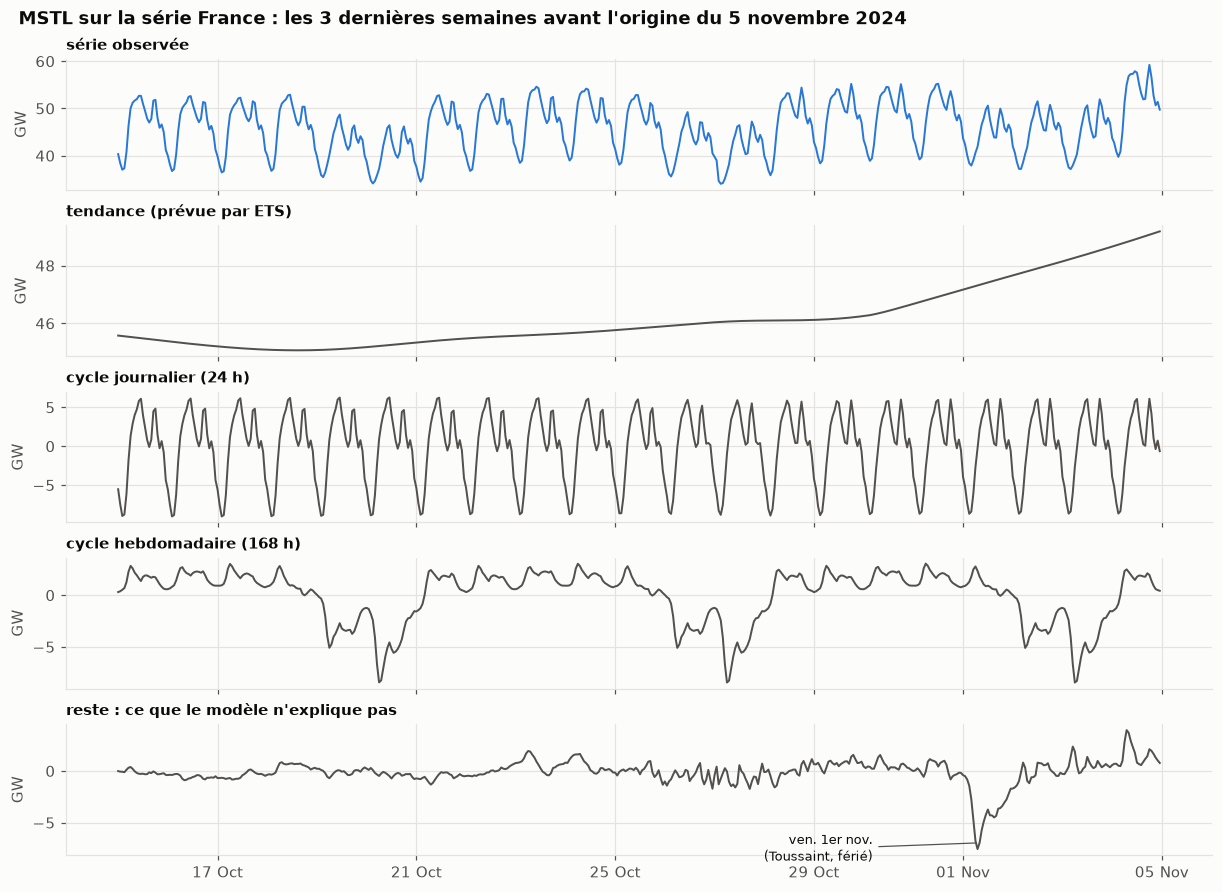

écart-type des composantes (GW) : trend 8.1, seasonal24 4.2, seasonal168 2.6, remainder 1.5


In [4]:
dec = (StatsForecast(models=[MSTL(season_length=[24, 168])], freq="h")
       .fit(train[train["unique_id"] == "France"]).fitted_[0, 0].model_)
dec.index = train[train["unique_id"] == "France"]["ds"].to_numpy()
last = dec.iloc[-3 * 168:] / 1000
parts = [("data", "série observée"), ("trend", "tendance (prévue par ETS)"),
         ("seasonal24", "cycle journalier (24 h)"), ("seasonal168", "cycle hebdomadaire (168 h)"),
         ("remainder", "reste : ce que le modèle n'explique pas")]
fig, axes = plt.subplots(len(parts), 1, figsize=(11, 8), sharex=True, layout="constrained")
for ax, (col, label) in zip(axes, parts):
    ax.plot(last.index, last[col], color=viz.BLUE if col == "data" else viz.TEXT_2, lw=1.3)
    ax.set_title(label, fontsize=10); ax.set_ylabel("GW")
toussaint = pd.Timestamp("2024-11-01 08:00")
axes[-1].annotate("ven. 1er nov.\n(Toussaint, férié)", (toussaint, last.loc[toussaint, "remainder"]),
                  xytext=(-70, -4), textcoords="offset points", ha="right", va="center", fontsize=8.5,
                  arrowprops={"arrowstyle": "-", "color": viz.TEXT_2, "lw": 0.8})
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
fig.suptitle("MSTL sur la série France : les 3 dernières semaines avant l'origine du 5 novembre 2024",
             x=0.01, ha="left", fontweight="semibold")
export(fig, "mstl_decomposition"); plt.show()
print("écart-type des composantes (GW) : " + ", ".join(f"{c} {dec[c].std() / 1000:.1f}" for c, _ in parts[1:]))

On lit la décomposition de haut en bas. La **tendance** monte avec l'automne (le chauffage). Le **cycle
journalier** domine. Le **cycle hebdomadaire** creuse les week-ends. Le **reste** est plat la plupart du temps,
mais plonge d'environ 7 GW le **1er novembre**, jour férié : MSTL ne connaît pas le calendrier, et traite ce
vendredi comme un vendredi ordinaire.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


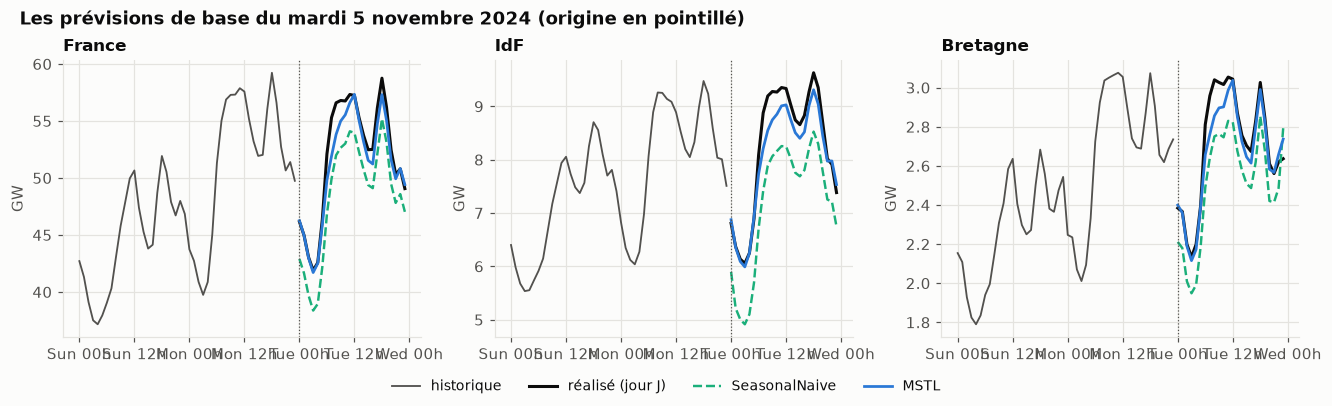

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), layout="constrained")
for ax, uid in zip(axes, ["France", "France/Île-de-France", "France/Bretagne"]):
    hist = train[(train["unique_id"] == uid) & (train["ds"] >= ORIGIN - pd.Timedelta(hours=48))]
    t = test[test["unique_id"] == uid]; f = Y_hat[Y_hat["unique_id"] == uid]
    ax.plot(hist["ds"], hist["y"] / 1000, color=viz.TEXT_2, lw=1.2, label="historique")
    ax.plot(t["ds"], t["y"] / 1000, color=viz.TEXT, lw=2, label="réalisé (jour J)")
    ax.plot(f["ds"], f["SeasonalNaive"] / 1000, color=viz.AQUA, lw=1.6, ls="--", label="SeasonalNaive")
    ax.plot(f["ds"], f["MSTL"] / 1000, color=viz.BLUE, lw=1.8, label="MSTL")
    ax.axvline(ORIGIN, color=viz.TEXT_2, lw=0.8, ls=":")
    ax.set_title(prepare.short_name(uid)); ax.set_ylabel("GW")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %Hh"))
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside lower center", ncols=4, fontsize=9)
fig.suptitle("Les prévisions de base du mardi 5 novembre 2024 (origine en pointillé)", x=0.01, ha="left",
             fontweight="semibold")
export(fig, "previsions_base"); plt.show()

## 3. Qui est cohérent ? Le naïf saisonnier l'est déjà

On mesure, heure par heure, l'écart entre la prévision du total France et la somme des prévisions des régions.

In [6]:
for model in ["SeasonalNaive", "MSTL"]:
    w = to_wide(Y_hat, order, model)
    gap = w["France"] - w[order[1:]].sum(axis=1)
    print(f"{model:13s} : incohérence max {gap.abs().max():8.1f} MW ; moyenne {gap.mean():+8.1f} MW")

SeasonalNaive : incohérence max      0.0 MW ; moyenne     +0.0 MW
MSTL          : incohérence max    444.8 MW ; moyenne   -374.7 MW


💡 **Pourquoi le naïf saisonnier est cohérent sans rien faire.** Sa prévision du total est la valeur du total
une semaine plus tôt, c'est-à-dire la somme des régions une semaine plus tôt, c'est-à-dire la somme de leurs
prévisions. C'est vrai de **toute méthode linéaire et commune à toutes les séries** appliquée à des données
additives : moyenne mobile, naïf, naïf saisonnier.

MSTL, lui, estime ses paramètres (lissage, tendance ETS) **séparément pour chaque série** : rien ne garantit que
les 13 modèles « s'additionnent ». Ici, la prévision France est inférieure à la somme des régions de 375 MW en
moyenne, et de 445 MW au pire : c'est l'arbitrage manuel que le comité de pilotage voudrait supprimer.

📌 **Conséquence pour le protocole.** Réconcilier SeasonalNaive ne changerait rien : `configs/eco2mix.yaml`
réconcilie donc **MSTL**, et garde SeasonalNaive comme baseline brute.

## 4. 🔬 H1 : les prévisions de base sont-elles sans biais ?

MinT **préserve** l'absence de biais, il ne la **crée** pas (bloc 4) : un biais sur une seule série est réparti
sur toutes. On teste donc la moyenne des résidus in-sample de MSTL, série par série.

- **H0** : E[résidu] = 0, pour chaque série.
- **Test** : t de la moyenne avec erreur-type **HAC** (Newey-West, ⌈1,3 √n⌉ retards), puis correction de **Holm**
  pour les 13 tests. Le t naïf (écart-type / √n), qui suppose des heures indépendantes, est affiché en regard.

In [7]:
E = (to_wide(Y_fit, order, "y") - to_wide(Y_fit, order, "MSTL")).dropna()
E.columns = [prepare.short_name(c) for c in E.columns]
bias = inference.bias_table(E)
bias = bias.join(inference.holm(bias["p"], cfg["inference"]["alpha"])[["p_holm", "rejet"]])
display(bias[["mean", "se_naive", "se_hac", "t_naif", "t", "p_holm", "rejet"]]
        .rename(columns={"mean": "moyenne (MW)", "se_naive": "e.-t. naïve", "se_hac": "e.-t. HAC",
                         "t": "t HAC", "rejet": "biais (Holm 5 %)"}))
print(f"retards HAC : {int(bias['lags'].iat[0])} ; T = {len(E):,} heures")
print(f"rapport e.-t. HAC / naïve : médiane {(bias['se_hac'] / bias['se_naive']).median():.2f}")

,moyenne (MW),e.-t. naïve,e.-t. HAC,t_naif,t HAC,p_holm,biais (Holm 5 %)
France,-0.292,2.626,2.372,-0.111,-0.123,1.0,False
AURA,-0.041,1.010,0.585,-0.040,-0.069,1.0,False
BFC,-0.011,0.297,0.204,-0.036,-0.053,1.0,False
Bretagne,-0.023,0.260,0.151,-0.090,-0.154,1.0,False
Centre-VdL,-0.018,0.471,0.255,-0.037,-0.069,1.0,False
Grand Est,-0.010,0.791,0.490,-0.012,-0.020,1.0,False
HdF,-0.047,0.864,0.435,-0.054,-0.107,1.0,False
Normandie,-0.025,0.389,0.288,-0.064,-0.086,1.0,False
N.-Aquitaine,-0.079,0.619,0.522,-0.127,-0.150,1.0,False
Occitanie,-0.123,0.863,0.557,-0.142,-0.220,1.0,False


retards HAC : 122 ; T = 8,736 heures
rapport e.-t. HAC / naïve : médiane 0.65


**Conclusion du test : H0 n'est rejetée pour aucune série, mais ce test ne prouve rien.** Les moyennes
résiduelles valent quelques dixièmes de MW, pour des séries de plusieurs milliers de MW. Ce n'est pas une
bonne nouvelle, c'est **mécanique** : le résidu de MSTL est le *reste* d'une décomposition, centré par
construction. Un modèle biaisé hors échantillon peut très bien avoir des résidus in-sample de moyenne nulle.

⚠️ **Point d'attention — le HAC n'agrandit pas toujours l'erreur-type.** Ici, l'erreur-type HAC est plus
**petite** que l'erreur-type naïve. La correction HAC tient compte du signe des autocorrélations : quand elles
sont négatives à certains retards (§ 5), la variance de la moyenne est plus faible qu'en cas d'indépendance.
L'intuition « autocorrélation = moins d'information » n'est vraie que pour une autocorrélation positive.

📌 **Le test de biais utile se fait sur les erreurs hors échantillon**, sur les 119 origines de l'étude de
robustesse (notebook 04).

## 5. 🔬 H2 : les résidus sont-ils du bruit blanc ?

- **H0** (Ljung-Box) : pas d'autocorrélation des résidus jusqu'au retard k, pour k = 24 et k = 168.
- **Pourquoi c'est important.** Si les résidus ont de la structure, ils ne se comportent pas comme des erreurs
  de prévision à un pas, et W, estimée sur eux, peut mal représenter les vraies erreurs.

H0 rejetée (p < 0,05) pour 13 séries sur 13, aux deux retards ; plus grande p-valeur : 4.5e-87


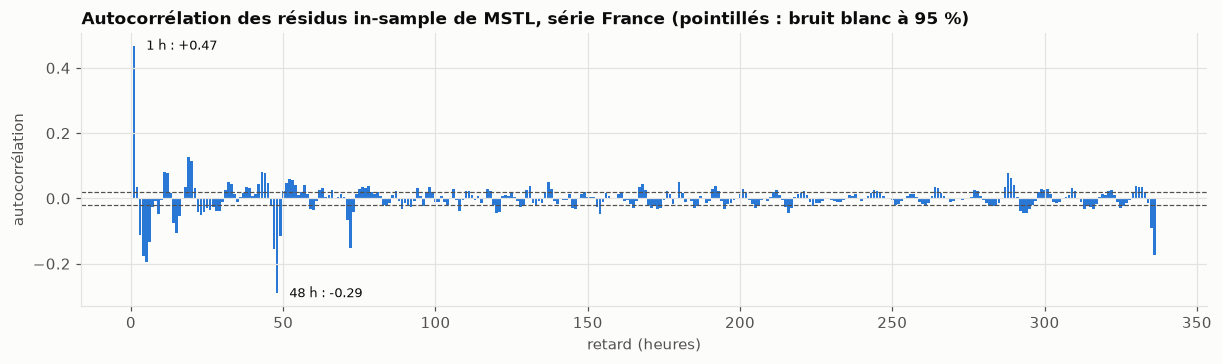

somme des autocorrélations, retards 1 à 336 : -0.36


In [8]:
lb = pd.DataFrame({c: inference.ljung_box(E[c].to_numpy())["lb_pvalue"].to_numpy() for c in E.columns},
                  index=["p (k = 24)", "p (k = 168)"]).T
print(f"H0 rejetée (p < 0,05) pour {(lb < 0.05).all(axis=1).sum()} séries sur {len(lb)}, aux deux retards ; "
      f"plus grande p-valeur : {lb.to_numpy().max():.1e}")
a = acf(E["France"], nlags=336, fft=True)
fig, ax = plt.subplots(figsize=(11, 3.2), layout="constrained")
ax.bar(range(1, 337), a[1:], width=0.9, color=viz.BLUE)
for sign in (1, -1):
    ax.axhline(sign * 1.96 / np.sqrt(len(E)), color=viz.TEXT_2, ls="--", lw=0.8)
for k, txt in [(1, "1 h"), (48, "48 h")]:
    ax.annotate(f"{txt} : {a[k]:+.2f}", (k, a[k]), xytext=(8, 0), textcoords="offset points", va="center",
                fontsize=8.5)
ax.set_xlabel("retard (heures)"); ax.set_ylabel("autocorrélation")
ax.set_title("Autocorrélation des résidus in-sample de MSTL, série France (pointillés : bruit blanc à 95 %)")
export(fig, "acf_residus"); plt.show()
print(f"somme des autocorrélations, retards 1 à 336 : {a[1:].sum():+.2f}")

**Conclusion du test.** H0 est **rejetée pour toutes les séries**. La forme de l'autocorrélation est
instructive :

- au retard 1 h, elle est **positive** et forte (une heure mal décrite est suivie d'une autre) ;
- autour de 3 à 6 h et de 48 h, elle devient **négative**. Ce n'est pas un comportement d'erreur de prévision :
  c'est la signature d'un **lissage bilatéral**. MSTL estime ses cycles avec un lisseur qui regarde avant **et**
  après chaque instant, et ce qu'il prend en trop à une heure, il le rend à une heure voisine.

💡 **Ce que cela veut dire.** Les résidus in-sample de MSTL ne sont **pas** des erreurs de prévision à un pas.
C'est une hypothèse implicite de `mint_shrink` (et de `wls_var`) qui ne tient pas ici. Le § 7 en mesure la
conséquence. C'est aussi pourquoi l'erreur-type HAC du § 4 est plus petite que l'erreur-type naïve : la somme
des autocorrélations est négative.

## 6. 🔬 H3 : la matrice W

MinT shrink estime W à partir des résidus in-sample, avec le shrinkage de Schäfer-Strimmer (bloc 2). Trois
questions :

1. les résidus sont-ils **corrélés** entre régions (sinon, W est presque diagonale) ?
2. la covariance empirique W₁ est-elle **bien conditionnée** (sinon, MinT est numériquement instable) ?
3. combien de **shrinkage** faut-il ?

T = 8,736 heures, m = 13 séries : T / m = 672
corrélation moyenne entre régions : 0.11 (min -0.24, max 0.44)
corrélation France / régions : 0.40 en moyenne
λ de Schäfer-Strimmer : 0.0236
conditionnement : W₁ 210 -> W shrink 171


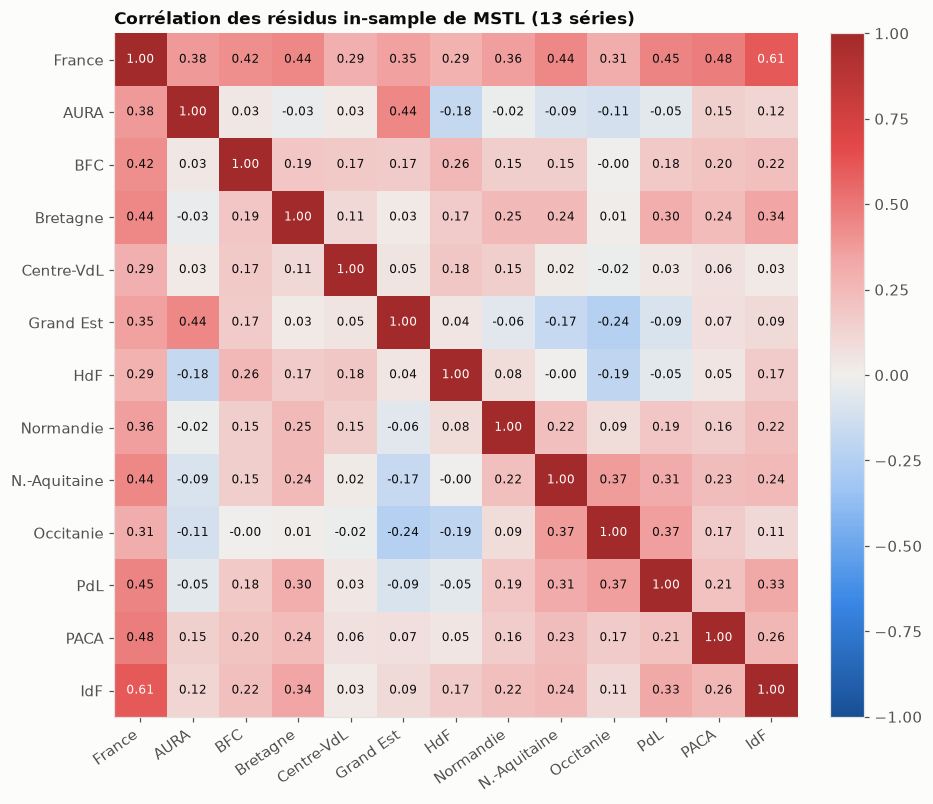

In [9]:
cov = shrunk_covariance(E.to_numpy(), base="library")
R = E.corr()
leaves = R.iloc[1:, 1:].to_numpy()[~np.eye(12, dtype=bool)]
print(f"T = {len(E):,} heures, m = {E.shape[1]} séries : T / m = {len(E) / E.shape[1]:.0f}")
print(f"corrélation moyenne entre régions : {leaves.mean():.2f} (min {leaves.min():.2f}, max {leaves.max():.2f})")
print(f"corrélation France / régions : {R.iloc[0, 1:].mean():.2f} en moyenne")
print(f"λ de Schäfer-Strimmer : {cov.lam:.4f}")
print(f"conditionnement : W₁ {np.linalg.cond(cov.W1):,.0f} -> W shrink {cov.condition_number:,.0f}")
fig, ax = plt.subplots(figsize=(8.5, 7.2), layout="constrained")
viz.heatmap(ax, R.to_numpy(), list(R.columns), title="Corrélation des résidus in-sample de MSTL (13 séries)",
            diverging=True, fmt="{:.2f}", vmax=1)
export(fig, "correlation_residus"); plt.show()

**Lecture, question par question.**

1. **Les résidus in-sample sont peu corrélés entre régions** : 0,11 en moyenne, et parfois négativement.
   Comparez avec le notebook 01 : les erreurs du naïf saisonnier, elles, étaient corrélées à 0,73. Les chocs
   communs à tout le pays (froid, jours fériés) **disparaissent des résidus de MSTL**, parce que le lisseur les
   absorbe dans la tendance et les cycles. Mais ils ne disparaîtront pas des erreurs de prévision, puisque le
   lendemain, le lisseur ne les connaît pas encore.
2. **W₁ est bien conditionnée** (de l'ordre de 200) : avec 672 heures par série, l'estimation est stable.
3. **λ est petit** (environ 0,02) : avec autant d'heures pour 13 séries, les corrélations estimées sont
   précises, et le shrinkage a peu à corriger.

⚠️ **Point d'attention — « bien estimée » ne veut pas dire « juste ».** W est estimée avec précision… sur des
résidus qui ne ressemblent pas aux erreurs qu'elle doit décrire. Une estimation précise d'une mauvaise cible
reste une mauvaise cible. C'est l'objet du § 7, et du test complet du notebook 04.

## 7. ⚠️ L'hypothèse cachée : les résidus in-sample ressemblent-ils aux vraies erreurs ?

MinT utilise W pour pondérer les **erreurs de prévision à l'horizon h**, mais l'estime sur les **résidus
in-sample**. Le § 5 a montré que ces résidus sont des restes de lissage, pas des erreurs de prévision.

🧪 On compare l'écart-type des résidus in-sample à l'erreur absolue moyenne réelle du jour J, à cette origine :

In [10]:
err = to_wide(test, order) - to_wide(Y_hat, order, "MSTL")
err.columns = E.columns
comp = pd.DataFrame({"résidus in-sample, écart-type (MW)": E.std(), "erreur réelle du jour J, |moyenne| (MW)": err.abs().mean()})
comp["rapport"] = comp.iloc[:, 1] / comp.iloc[:, 0]
display(comp.T.round(1))

,France,AURA,BFC,Bretagne,Centre-VdL,Grand Est,HdF,Normandie,N.-Aquitaine,Occitanie,PdL,PACA,IdF
"résidus in-sample, écart-type (MW)",245.5,94.4,27.7,24.3,44.0,73.9,80.8,36.4,57.9,80.6,40.3,33.1,60.3
"erreur réelle du jour J, |moyenne| (MW)",906.4,112.0,80.9,56.7,75.0,97.3,163.6,73.7,65.8,120.7,72.0,55.9,248.7
rapport,3.7,1.2,2.9,2.3,1.7,1.3,2.0,2.0,1.1,1.5,1.8,1.7,4.1


Les erreurs réelles du jour J sont **de 1,1 à 4 fois** plus grandes que les résidus in-sample, et le rapport
varie beaucoup d'une série à l'autre (3,7 pour la France, 4,1 pour l'Île-de-France, 1,1 pour la
Nouvelle-Aquitaine). Sur une seule origine et 24 heures, ce n'est qu'un indice.

💡 **Pourquoi l'échelle seule ne gênerait pas MinT, mais la structure si.** La formule G = (S′W⁻¹S)⁻¹S′W⁻¹ ne
change pas si l'on multiplie W par une constante. MinT n'a donc besoin que d'une W **proportionnelle** à la vraie
covariance des erreurs à 24 h. Deux choses cassent cette proportionnalité ici :

- le rapport n'est **pas le même** pour toutes les séries : W sous-estime certaines plus que d'autres, et MinT
  leur fait trop confiance ;
- les **corrélations** ne sont pas les mêmes : les résidus sont presque indépendants entre régions (§ 6), alors
  que les erreurs de prévision subissent les chocs nationaux.

Le notebook 04 teste les deux sur 119 origines.

📌 **À retenir — les modèles de base et les hypothèses.**
- **SeasonalNaive est cohérent par construction** (méthode linéaire, commune à toutes les séries) : on
  réconcilie MSTL, dont l'incohérence atteint plusieurs centaines de MW.
- 🔬 **H1 (biais)** : non rejetée, mais **non informative** : les résidus de MSTL sont centrés par construction.
  Le vrai test est hors échantillon.
- 🔬 **H2 (bruit blanc)** : rejetée partout. L'autocorrélation négative à 3-6 h et 48 h trahit un lissage
  bilatéral : les résidus de MSTL ne sont pas des erreurs de prévision.
- 🔬 **H3 (W)** : bien conditionnée, peu de shrinkage, mais des corrélations entre régions faibles, très
  différentes de celles des vraies erreurs.
- ⚠️ **L'hypothèse cachée de `mint_shrink`** (W in-sample ∝ covariance des erreurs à 24 h) est fragile avec
  MSTL. C'est la piste principale pour interpréter les résultats des notebooks 03 et 04.